# Can the graph help us guess what a paper is about?

Imagine 2,708 academic papers. Some cite each other; the rest don't. We know what
the cited papers are about — *Neural Networks*, *Probabilistic Methods*, *Theory*,
and four other subject areas. We're handed a brand-new paper and asked to guess
its subject.

Two clues are available.

* **The words in the paper** — a binary indicator for each of 1,433 vocabulary words.
* **The citations** — who this paper cites, and who cites it.

If your gut says "obviously the words", you're not wrong. The interesting question
is different: **once the words have done their job, is there anything left for the
graph to add?** And if the graph has something to say, *what exactly does it say?*

That's the slide-deck framing of NS20: traditional ML on graphs is the practice of
designing hand-crafted features about each node and feeding them to an off-the-shelf
classifier. Two phases — *engineer features* (Phase 1, slide 7), then
*train and predict* (Phase 2).

## Setting up the testbed

The dataset is **CORA** — a citation graph of computer-science papers. It's the
canonical small benchmark for node classification: small enough that everything
runs in seconds, real enough that the comparisons mean something.

In [1]:
from netsci_utils import *           # re-exports nx, np, plt; calls setup_matplotlib()
set_seeds()                          # RANDOM_SEED = 42 for python random + numpy
%matplotlib inline

import ast, warnings, random
import pandas as pd
import seaborn as sns

from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.ensemble           import RandomForestClassifier
from sklearn.model_selection    import StratifiedKFold, train_test_split
from sklearn.metrics            import (accuracy_score, f1_score,
                                        confusion_matrix, classification_report)
from scipy                      import stats

warnings.filterwarnings("ignore")


In [2]:
# Two CSVs: one row per paper (with its 1,433-word feature vector and subject),
# and one row per citation.
nodes_df = pd.read_csv("../datasets/cora/nodes.csv")
edges_df = pd.read_csv("../datasets/cora/edges.csv")

G = nx.DiGraph()
for _, row in nodes_df.iterrows():
    G.add_node(row["nodeId"],
               subject  = row["subject"],
               # ast.literal_eval safely parses the literal "[0, 1, 0, ...]" string
               # — never use plain eval() on file contents.
               features = ast.literal_eval(row["features"]))
for _, e in edges_df.iterrows():
    G.add_edge(e["sourceNodeId"], e["targetNodeId"])

# Relabel nodes to 0..N-1 so node IDs line up with row indices in our matrices
G = nx.relabel_nodes(G, {n: i for i, n in enumerate(G.nodes())})

print(f"  papers   = {G.number_of_nodes():,}")
print(f"  citations = {G.number_of_edges():,}")
print(f"  density   = {nx.density(G):.5f}   (very sparse — most papers cite very few others)")


  papers   = 2,708
  citations = 10,556
  density   = 0.00144   (very sparse — most papers cite very few others)


In [3]:
# Pull out the per-node arrays we'll use again and again
X_content = np.array([G.nodes[n]["features"] for n in G.nodes()], dtype=float)
y_text    = np.array([G.nodes[n]["subject"]  for n in G.nodes()])

print("Class balance:")
print(pd.Series(y_text).value_counts().to_string())


Class balance:
Neural_Networks           818
Probabilistic_Methods     426
Genetic_Algorithms        418
Theory                    351
Case_Based                298
Reinforcement_Learning    217
Rule_Learning             180


Seven subject classes, with *Neural Networks* the largest (818 papers) and
*Rule Learning* the smallest (180). Imbalanced but not pathological.

To make the rest of the notebook concrete, we'll keep referring back to **two
specific papers** chosen to be opposites: a well-cited central paper, and a
peripheral leaf with hardly any links. Watch what each feature says about them.

In [4]:
# Pick a high-degree hub and a low-degree leaf, both in the largest class
ud_deg = dict(G.to_undirected().degree())
nn_papers = [n for n in G.nodes() if G.nodes[n]["subject"] == "Neural_Networks"]
HUB  = max(nn_papers, key=ud_deg.get)         # most-connected NN paper
LEAF = min((n for n in nn_papers if ud_deg[n] >= 1), key=ud_deg.get)

print(f"HUB   — paper #{HUB}, subject = {G.nodes[HUB]['subject']},   degree = {ud_deg[HUB]}")
print(f"LEAF  — paper #{LEAF}, subject = {G.nodes[LEAF]['subject']}, degree = {ud_deg[LEAF]}")


HUB   — paper #747, subject = Neural_Networks,   degree = 74
LEAF  — paper #7, subject = Neural_Networks, degree = 1


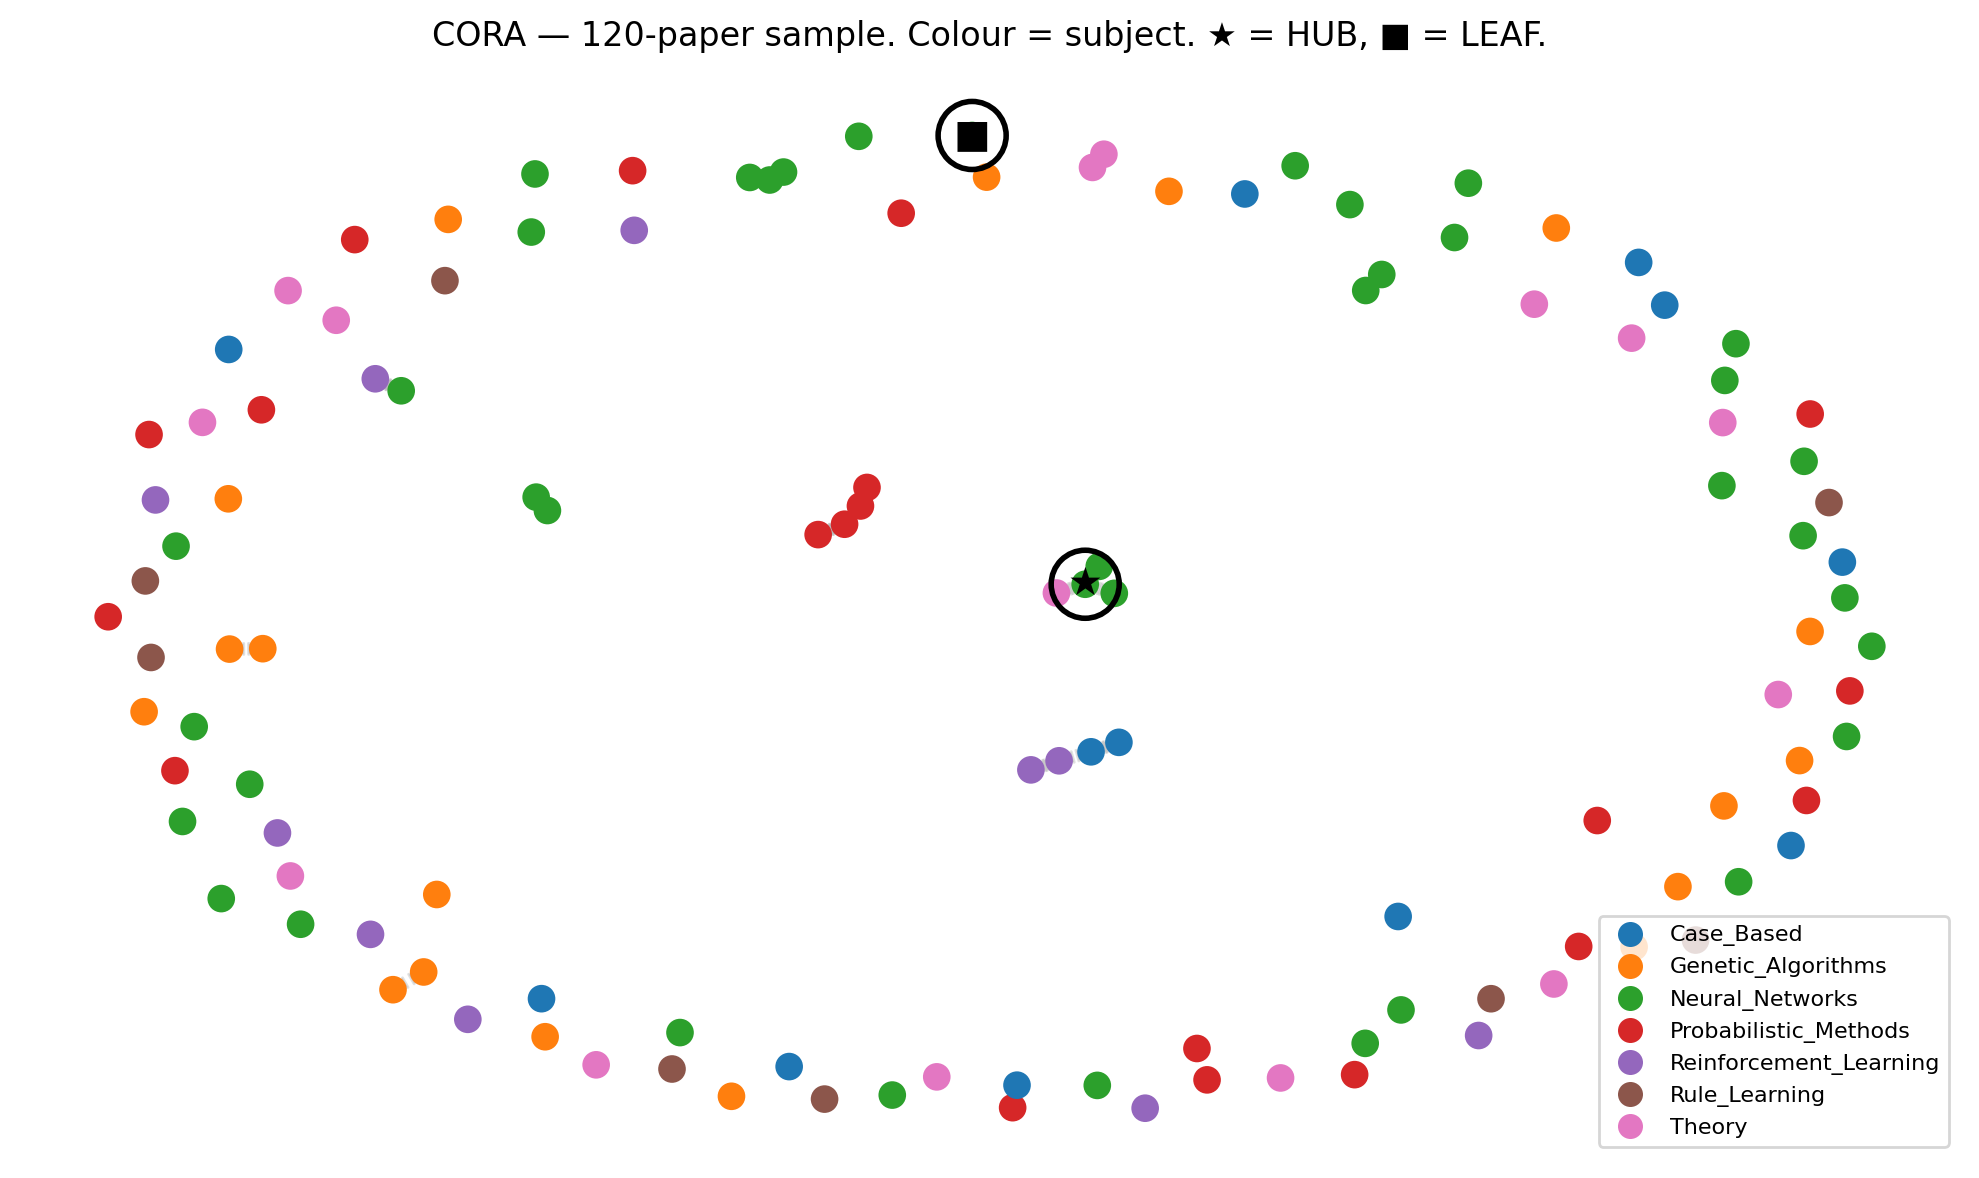

In [5]:
# Quick visual: a 120-node random subgraph, coloured by subject,
# with our two reference papers highlighted.
sample = random.sample(list(G.nodes()), 120)
for n in (HUB, LEAF):
    if n not in sample:
        sample.append(n)
H = G.subgraph(sample).copy()

subjects   = sorted({G.nodes[n]["subject"] for n in sample})
subj_color = {s: c for s, c in zip(subjects, plt.cm.tab10.colors)}

plt.figure(figsize=FIGURE_SIZE)
pos = nx.spring_layout(H, seed=RANDOM_SEED)
nx.draw_networkx_edges(H, pos, alpha=0.25, edge_color=EDGE_COLOR)
nx.draw_networkx_nodes(H, pos, node_size=80,
    node_color=[subj_color[G.nodes[n]['subject']] for n in H.nodes()])

# overlay HUB and LEAF
for n, marker in [(HUB, "★"), (LEAF, "■")]:
    if n in H:
        x, y = pos[n]
        plt.scatter([x], [y], s=600, facecolors="none",
                    edgecolors="black", linewidths=2, zorder=3)
        plt.annotate(marker, (x, y), ha="center", va="center", fontsize=14, zorder=4)

plt.axis("off")
plt.title("CORA — 120-paper sample. Colour = subject. ★ = HUB, ■ = LEAF.")
handles = [plt.Line2D([0],[0], marker="o", linestyle="", color=c, label=s, markersize=8)
           for s, c in subj_color.items()]
plt.legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()


## First attempt: just use the words

Before we touch the graph, let's establish the *words-only* baseline. If we
remove every citation and feed only the 1,433-dim bag-of-words to a classifier,
how well do we do?

We use a **Random Forest** (200 trees) and **5-fold stratified cross-validation**
so the held-out samples reflect the class balance.

In [6]:
le = LabelEncoder()
y  = le.fit_transform(y_text)

def cv_score(name, X, y, n_splits=5, scale_from=None):
    """5-fold stratified CV with a RandomForest. Returns per-fold accuracies and F1s.

    `scale_from`: index where the network features start. We standardise those
                  columns *inside each CV fold* — fitting the scaler on the
                  training half only — so test statistics never sneak into
                  training. (The 0/1 word indicators don't need scaling.)
    """
    accs, f1s = [], []
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    for tr, te in skf.split(X, y):
        Xt, Xv = X[tr].copy(), X[te].copy()
        if scale_from is not None:
            sc = StandardScaler().fit(Xt[:, scale_from:])
            Xt[:, scale_from:] = sc.transform(Xt[:, scale_from:])
            Xv[:, scale_from:] = sc.transform(Xv[:, scale_from:])
        clf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED, n_jobs=-1)
        clf.fit(Xt, y[tr])
        p = clf.predict(Xv)
        accs.append(accuracy_score(y[te], p))
        f1s .append(f1_score(y[te], p, average="macro"))
    print(f"  {name:25s}  acc = {np.mean(accs):.3f} ± {np.std(accs):.3f}    "
          f"macro-F1 = {np.mean(f1s):.3f}")
    return accs, f1s

print("Words-only baseline:")
acc_c, f1_c = cv_score("content (1433 words)", X_content, y)


Words-only baseline:


  content (1433 words)       acc = 0.765 ± 0.013    macro-F1 = 0.746


About **76 %** accuracy with words alone. For seven classes, that's a strong
starting point — random would be ~14 %. The question is whether the graph can
push this further.

## What can the graph tell us about a single node?

Now turn off the words and pretend we only have the citation structure. What
could we possibly say about a paper from its position in the graph?

NS20 slide 11 splits node features into two intuitions:

* **Importance-based** — *how prominent is this node?* (degree, centrality)
* **Structure-based** — *what does the local topology look like?* (clustering, graphlets)

We'll build one block of each. After every block, we'll print the values for
our HUB ★ and LEAF ■ so you can feel what each feature *captures*.

### Importance features (slide 12)

The intuition is: *important* nodes have many connections, sit on many shortest
paths, are pointed at by other important nodes, and so on. Five standard
measures, each a NetworkX one-liner.

* **degree** — count of neighbours. Crude but informative.
* **eigenvector centrality** — you're important if your neighbours are important.
* **betweenness** — fraction of shortest paths that pass through you.
* **closeness** — inverse mean shortest-path distance to everyone else.
* **PageRank** — random-walker stationary probability. Technically introduced in
  NS19 (Link Analysis), but it complements eigenvector centrality on directed
  graphs and is too useful to leave out.

In [7]:
def importance_features(G):
    """Five 'how prominent is this node?' features, slide 12.

    We deliberately omit a top-level `degree` column here: the GDV section
    below already includes orbit `g_a_degree`, which IS the (undirected)
    degree, so adding `degree` here would duplicate that signal and inflate
    its weight in any model that sees both. We keep `in_degree` and
    `out_degree` to preserve the directional info — even though on CORA the
    raw dataset stores citations as mutual pairs, so they happen to coincide.
    """
    Gu = G.to_undirected()
    return pd.DataFrame({
        "in_degree":   dict(G.in_degree()),
        "out_degree":  dict(G.out_degree()),
        "pagerank":    nx.pagerank(G, alpha=0.85),
        # Approximated betweenness on k=500 sampled source nodes (~18% of CORA).
        # Much faster than exact and reproducible thanks to seed=RANDOM_SEED.
        # For an exact computation, drop the k= argument.
        "betweenness": nx.betweenness_centrality(Gu, k=500, seed=RANDOM_SEED, normalized=True),
        "closeness":   nx.closeness_centrality(Gu),
        "eigenvector": nx.eigenvector_centrality(Gu, max_iter=1000, tol=1e-6),
    })

F_imp = importance_features(G)

print("Our two reference papers, side-by-side:")
print(F_imp.loc[[HUB, LEAF]].T.round(5))


Our two reference papers, side-by-side:
                  747      7  
in_degree    74.00000  1.00000
out_degree   74.00000  1.00000
pagerank      0.00625  0.00012
betweenness   0.08658  0.00000
closeness     0.20324  0.12509
eigenvector   0.00787  0.00000


The HUB scores higher on every measure — that's exactly what these features
are designed to capture. But notice the *shape* of the gap:

* **eigenvector** — HUB ~0.008, LEAF ~0.000  →  the LEAF score doesn't just
  *look* like zero, it *is* effectively zero. Eigenvector centrality compounds:
  it asks "are your neighbours important?", and the LEAF's single neighbour
  isn't, and *that* neighbour's neighbours aren't either, so the score collapses.
* **betweenness** — HUB 0.087, LEAF 0  →  the LEAF lies on no shortest path
  between any two nodes; the HUB lies on ~9 % of them. Closeness shows the
  same pattern more gently because every node has *some* finite distance.

You'll also see that `in_degree == out_degree` for both papers. That's a
CORA-specific quirk (citations stored as mutual pairs), not a general property
of citation networks. We don't include a `degree` column here because the
GDV's `g_a_degree` (computed below) already captures the undirected count —
no point feeding the classifier two identical columns.

The takeaway: each importance feature emphasises a slightly different aspect
of "being central". A classifier that sees them all gets to mix them.

### Structure features, part 1 — the clustering coefficient (slide 13)

The clustering coefficient asks: *of all the pairs of my neighbours, what
fraction are themselves connected?* 1.0 means you're inside a fully-connected
clique; 0.0 means none of your friends know each other.

It's a structural feature because it doesn't care how *important* you are — it
only cares about *what your neighbourhood looks like*.

In [8]:
clustering = pd.DataFrame({"clustering": nx.clustering(G.to_undirected())})
print("Clustering for our two papers:")
print(clustering.loc[[HUB, LEAF]])


Clustering for our two papers:
     clustering
747    0.006294
7      0.000000


### Structure features, part 2 — graphlets and the GDV (slides 14–16)

A **graphlet** is a small connected subgraph pattern. Inside a graphlet, nodes
don't all play the same role — they can sit in different *positions*, called
**orbits**. The orbit, not just the pattern, is what matters.

The full picture (slide 14): graphlets up to 5 nodes have **73 distinct
orbits**, so the **Graphlet Degree Vector (GDV)** of a node is a 73-dimensional
count vector — for each orbit, how many graphlets touch this node *in that
position?*

Computing the full 73-orbit GDV needs a dedicated tool like
[ORCA](https://file.biolab.si/biolab/supp/orca/) or
[`graphlet-counter`](https://pypi.org/project/graphlet-counter/) — they use
combinatorial tricks to avoid the naive $\mathcal{O}(n^k)$ cost.

For this notebook we compute a **simplified 4-orbit GDV** (undirected view of
the citation graph) that matches the slide's worked example (slide 16, where
it shows GDV(u) = [2, 1, 0, 2]). These four orbits cover all graphlets up to
3 nodes:

```
   g_a  edge          •—•              u is one of the two endpoints
   g_b  3-path end    •—•—u            u is the END of a length-2 path
   g_c  3-path mid    •—u—•            u is the MIDDLE — connecting two non-friends
   g_d  triangle      •—u—•            u is a corner of a closed triangle
                       \ /
                        •
```

A subtle but important point: `g_b` and `g_c` are the *same shape* (a 3-path),
but the role *inside* the shape is different — and so the count is different.
That's the whole idea of orbit-based features.

| Orbit | Pattern | What it counts for node *u* |
|---|---|---|
| `g_a` | edge — 2 nodes | how many (undirected) neighbours *u* has |
| `g_b` | 3-path, *end* | how many length-2 paths *terminate* at *u* |
| `g_c` | 3-path, *middle* | how many length-2 paths *pass through* *u* |
| `g_d` | triangle | how many triangles touch *u* |

These four numbers already give a much richer fingerprint than degree alone.
Drop in ORCA when you need the full 73.

In [9]:
def graphlet_features(G):
    """Simplified 4-orbit GDV — the orbits from the slide-16 worked example."""
    Gu  = G.to_undirected()
    deg = dict(Gu.degree())
    tri = nx.triangles(Gu)               # exact triangle count per node

    rows = {}
    for u in Gu.nodes():
        d, t = deg[u], tri[u]
        nb   = list(Gu.neighbors(u))
        # Centre of a 3-path = pairs of neighbours that are NOT themselves connected.
        # = (d choose 2) − triangles_at_u
        g_c_centre = max(0, d * (d - 1) // 2 - t)
        # End of a 3-path v—w—u: for each neighbour w, count w's other neighbours
        # (excluding u). Triangles get double-counted, hence the −2t correction.
        g_b_end    = sum(deg[w] - 1 for w in nb) - 2 * t
        rows[u] = {"g_a_degree": d, "g_b_path_end": g_b_end,
                   "g_c_path_mid": g_c_centre, "g_d_triangle": t}
    return pd.DataFrame.from_dict(rows, orient="index")

F_gdv = graphlet_features(G)

print("4-orbit GDV for our two papers:")
print(F_gdv.loc[[HUB, LEAF]])


4-orbit GDV for our two papers:
     g_a_degree  g_b_path_end  g_c_path_mid  g_d_triangle
747          74           125          2684            17
7             1            10             0             0


Look at `g_c_path_mid` for the HUB: 2,684. That's how many *open* 2-step paths
the HUB sits at the centre of — i.e., how often two of its neighbours are
*not* themselves connected. The LEAF, with only one neighbour, has nothing to
sit *in the middle of*: both `g_c_path_mid` and `g_d_triangle` are zero. But
notice that the LEAF's `g_b_path_end` is *not* zero — it's 10. Why? `g_b`
counts length-2 paths *terminating* at the LEAF, i.e. paths of the form
v—w—LEAF. The LEAF's single neighbour `w` itself has 10 other neighbours, so
there are 10 such paths even though the LEAF has no choices of its own.

That's the value of looking at orbits separately: the same neighbourhood can
be busy in one orbit and dead in another. On a *single* node these structural
counts will of course track the node's prominence — a hub touches more of
everything. But across the *whole network*, the *ratios* between them carry
information that pure degree doesn't: a node with high `g_d_triangle` lives in
a tightly-knit community, while a node with high `g_c_path_mid` and low
`g_d_triangle` is more of a *broker* connecting otherwise-disconnected
clusters. That's the role distinction the GDV adds.

### Assemble all the network features into one matrix

Eleven hand-crafted features per node — six in the importance family
(`in_degree`, `out_degree`, `pagerank`, `betweenness`, `closeness`,
`eigenvector`) and five in the structure family (`clustering` plus the four
GDV orbits). We sort by node ID so row *i* of the matrix corresponds to node
*i* in the graph.

In [10]:
F_net = pd.concat([F_imp, clustering, F_gdv], axis=1).sort_index()
X_net = F_net.values

print(f"Shape: {F_net.shape}\n")
print("Columns:")
for col in F_net.columns:
    family = "structure" if col in {"clustering", "g_a_degree", "g_b_path_end",
                                    "g_c_path_mid", "g_d_triangle"} else "importance"
    print(f"  ({family:10s})  {col}")


Shape: (2708, 11)

Columns:
  (importance)  in_degree
  (importance)  out_degree
  (importance)  pagerank
  (importance)  betweenness
  (importance)  closeness
  (importance)  eigenvector
  (structure )  clustering
  (structure )  g_a_degree
  (structure )  g_b_path_end
  (structure )  g_c_path_mid
  (structure )  g_d_triangle


## Does the network help?

Now the test. Three classifiers, same 5-fold setup as the words-only baseline:

1. **content only** — words, no graph. Our 76 % baseline.
2. **network only** — our 11 hand-crafted features. *No words at all.*
3. **content + network** — both concatenated.

In [11]:
X_all = np.hstack([X_content, X_net])

print("5-fold stratified CV, RandomForest(200 trees):\n")
acc_c, f1_c = cv_score("content only",      X_content, y)
acc_n, f1_n = cv_score("network only",      X_net,     y, scale_from=0)
acc_b, f1_b = cv_score("content + network", X_all,     y, scale_from=X_content.shape[1])


5-fold stratified CV, RandomForest(200 trees):



  content only               acc = 0.765 ± 0.013    macro-F1 = 0.746


  network only               acc = 0.586 ± 0.006    macro-F1 = 0.557


  content + network          acc = 0.777 ± 0.009    macro-F1 = 0.756


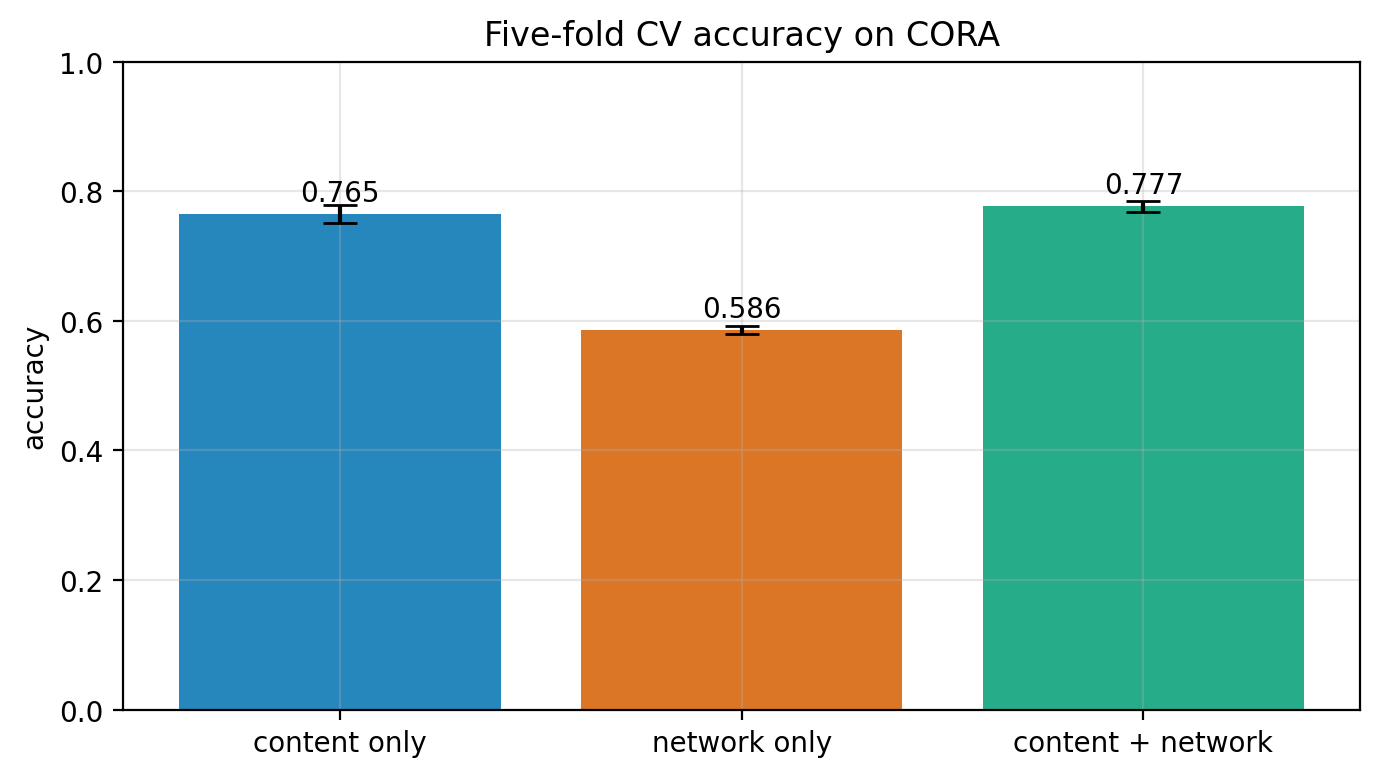

Paired t-test (content+net vs content): t = 1.94,  p = 0.125
  → adding network features is NOT statistically significant at α = 0.05


In [12]:
labels_   = ["content only", "network only", "content + network"]
acc_means = [np.mean(a) for a in (acc_c, acc_n, acc_b)]
acc_stds  = [np.std(a)  for a in (acc_c, acc_n, acc_b)]

plt.figure(figsize=(7, 4))
xpos = np.arange(3)
plt.bar(xpos, acc_means, yerr=acc_stds, capsize=6,
        color=["#0072B2", "#D55E00", "#009E73"], alpha=0.85)
plt.xticks(xpos, labels_)
plt.ylabel("accuracy"); plt.ylim(0, 1)
plt.title("Five-fold CV accuracy on CORA")
for i, v in enumerate(acc_means):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")
plt.tight_layout(); plt.show()

t, p = stats.ttest_rel(acc_b, acc_c)
print(f"Paired t-test (content+net vs content): t = {t:.2f},  p = {p:.3f}")
print(f"  → adding network features is "
      f"{'statistically significant' if p < 0.05 else 'NOT statistically significant'} at α = 0.05")


Three things to take away from this chart:

1. **Network features alone work** — about 58 %, well above random (1/7 = 14 %).
   The graph topology *is* informative about subject area, just from how papers
   cite each other.
2. **Words alone are strong** — ~76 %. CORA's bag-of-words is a hard baseline
   to beat.
3. **Combining them barely moves the needle.** The combined model nudges
   accuracy by less than a percentage point and the paired t-test says the
   difference isn't significant.

A caveat on that last result: a 5-fold paired t-test has only 5 paired
observations and 4 degrees of freedom, so it's a low-power test — only
*large* effects reach $p < 0.05$. What "not significant" means here is just
"any improvement is small," not "the improvement is exactly zero." For
sharper detection you'd want repeated CV (e.g. 5×2 or nested CV) — fine for
a quick sanity check at our scale, but worth flagging.

The next question — *why* doesn't the graph help once we already have the
words? — is what the rest of the notebook investigates.

## What does the model rely on?

A Random Forest can tell us, after training, *which features it actually used*.
For each feature, scikit-learn reports a number that says how much that feature
helped the trees split the classes apart — the bigger, the more the model
leaned on it. (Internally this is the average reduction in *Gini impurity*, a
measure of how mixed the classes are at a tree node — but you can read it as
"how much classification error this feature shaved off, on average".)

One important caveat before reading too much into the chart: Gini-based
feature importance is biased *towards features with many distinct values*.
A feature like `g_b_path_end`, which takes thousands of distinct counts,
gives the trees many possible split thresholds and therefore many
opportunities to look useful — even when its true signal is similar to a
coarser feature. We standardised the network features before fitting (so
*scale* isn't the issue), but cardinality bias remains. Treat the ranking as
*indicative* rather than authoritative; for a robustness check, permutation
importance (`sklearn.inspection.permutation_importance`) is the standard
follow-up.

We'll plot the ranking on the *network-only* model, colour-coded by the
slide-11 family scheme: **importance-based** (orange) vs. **structure-based**
(green).

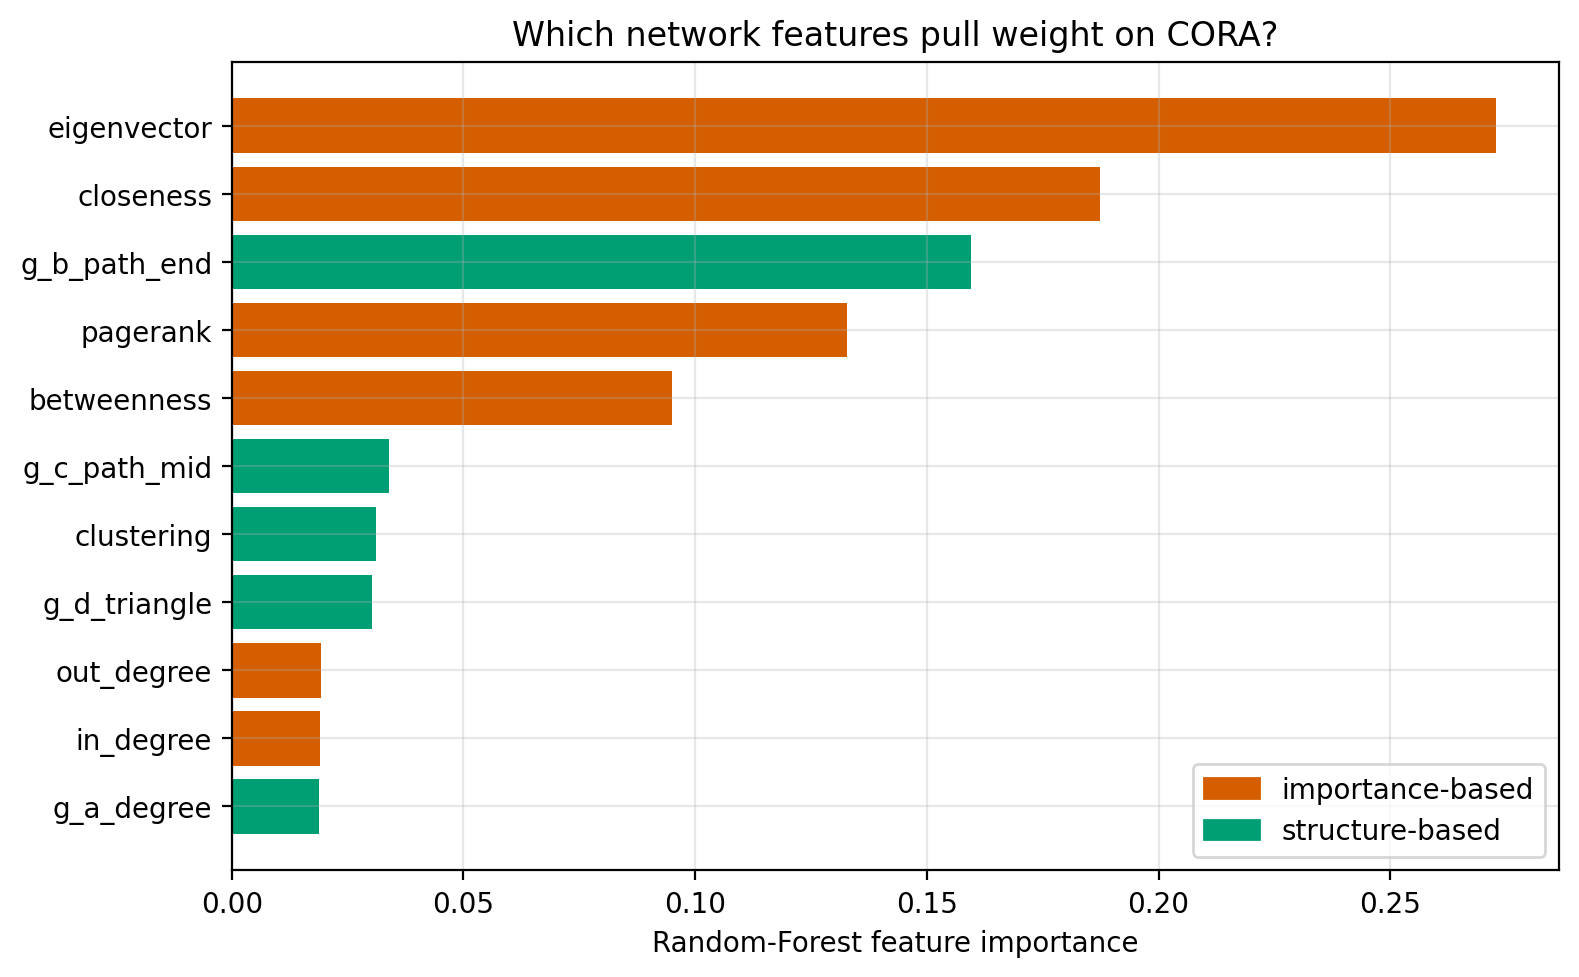

In [13]:
clf = RandomForestClassifier(n_estimators=400, random_state=RANDOM_SEED, n_jobs=-1)
clf.fit(StandardScaler().fit_transform(X_net), y)

structure_set = {"clustering", "g_a_degree", "g_b_path_end",
                 "g_c_path_mid", "g_d_triangle"}
imp = pd.DataFrame({
    "feature":    F_net.columns,
    "importance": clf.feature_importances_,
})
imp["family"] = imp["feature"].apply(
    lambda c: "structure-based" if c in structure_set else "importance-based")
imp = imp.sort_values("importance", ascending=True)

plt.figure(figsize=(8, 5))
colors = imp["family"].map({"importance-based": "#D55E00",
                            "structure-based":  "#009E73"})
plt.barh(imp["feature"], imp["importance"], color=colors)
plt.xlabel("Random-Forest feature importance")
plt.title("Which network features pull weight on CORA?")
handles = [plt.Rectangle((0,0),1,1, color=c, label=l) for l, c in
           [("importance-based","#D55E00"), ("structure-based","#009E73")]]
plt.legend(handles=handles, loc="lower right")
plt.tight_layout(); plt.show()


The model uses both families, but the heavy hitters are the *importance*
features (PageRank, eigenvector, betweenness, in/out degree). Among the
*structure* features only `g_b_path_end` carries real signal — and that one
already correlates strongly with degree.

So why doesn't this *help* on top of the words? Two-step argument:

1. **What "importance" features mostly tell the classifier:** "this paper is
   highly cited" / "this paper barely is". They're telling the model *how
   prominent* a node is, not *what topic* it's about.
2. **Why prominence is a topic-hint anyway:** in CORA the classes are
   uneven — *Neural Networks* has 818 papers, *Rule Learning* only 180. The
   subjects with more papers also tend to *attract* more citations, so
   "high-degree" weakly correlates with "is in a popular subject". That's a
   little bit of topic information, but only a little.

The bag-of-words *already knows* what topic each paper is on, with much higher
precision. So when we concatenate the two feature sets, the network features
have nothing new to contribute — they're a low-resolution version of a signal
the model already has at high resolution.

## Where does the model go wrong?

Looking at *failures* gives us the sharpest sense of what hand-crafted features
*can't* capture. We train one final time on a 70/30 split so we have a clean
held-out set to pick mistakes from.

Held-out accuracy: 0.761
Held-out macro-F1: 0.741



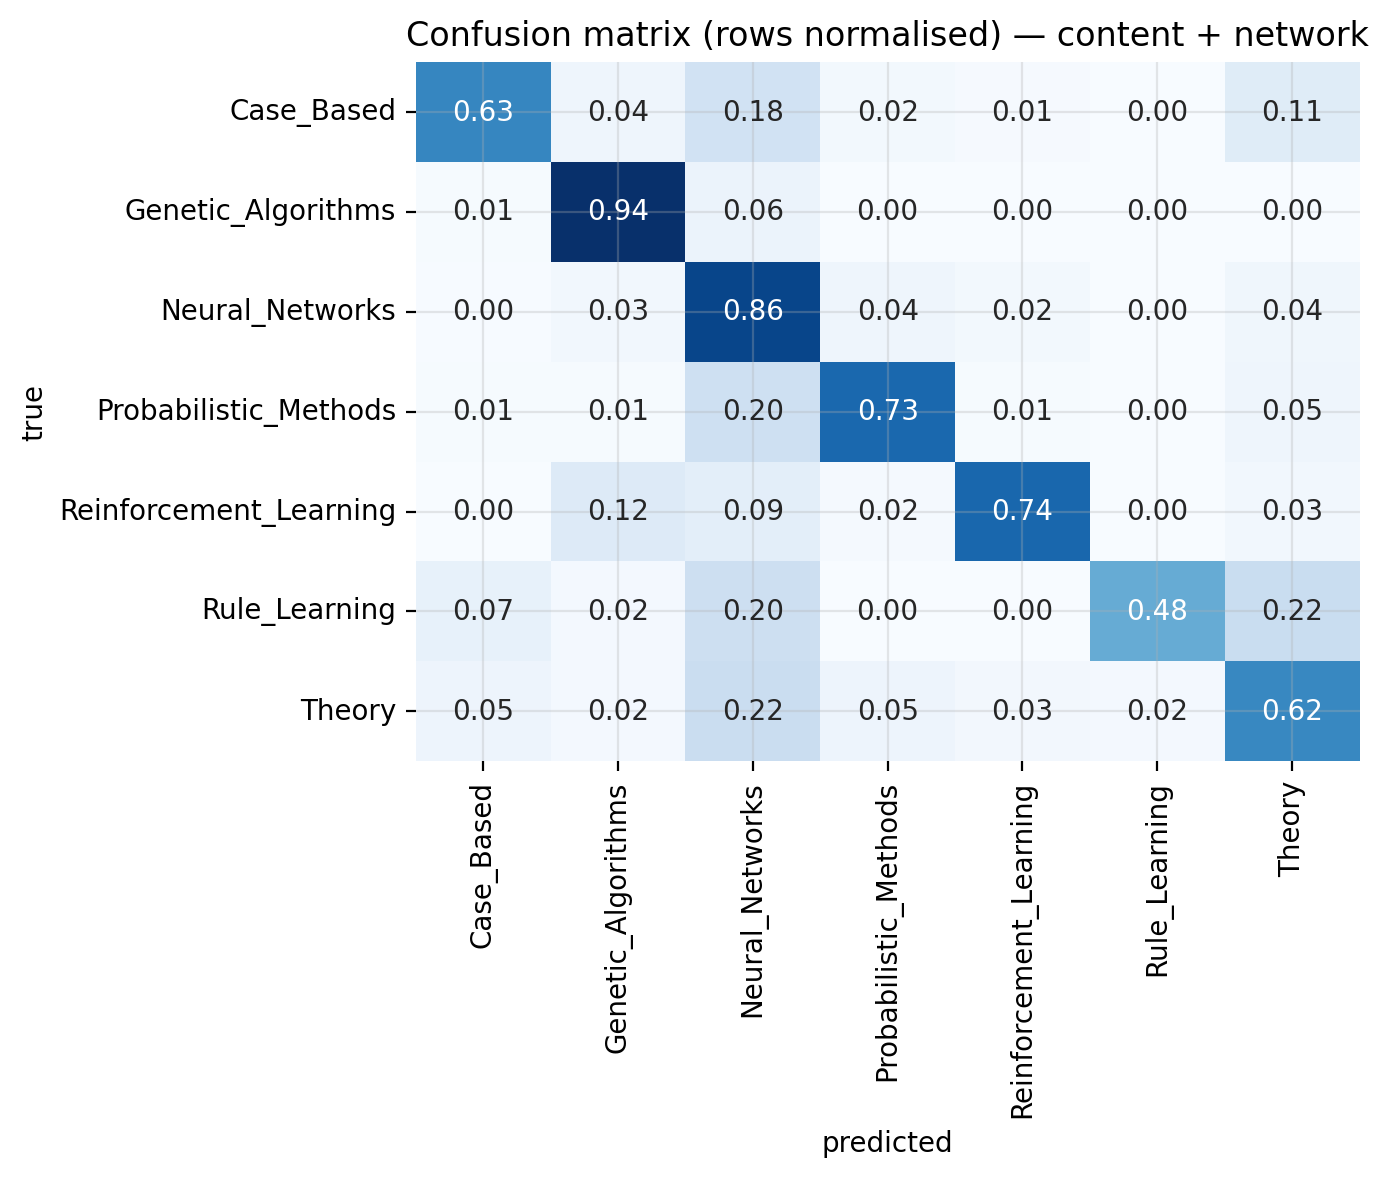

In [14]:
X = np.hstack([X_content, StandardScaler().fit_transform(X_net)])
Xtr, Xte, ytr, yte, idx_tr, idx_te = train_test_split(
    X, y, np.arange(len(y)), test_size=0.3, stratify=y, random_state=RANDOM_SEED)
clf = RandomForestClassifier(n_estimators=400, random_state=RANDOM_SEED, n_jobs=-1)
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)

print(f"Held-out accuracy: {accuracy_score(yte, pred):.3f}")
print(f"Held-out macro-F1: {f1_score(yte, pred, average='macro'):.3f}\n")

cm = confusion_matrix(yte, pred, normalize="true")
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, cbar=False)
plt.xlabel("predicted"); plt.ylabel("true")
plt.title("Confusion matrix (rows normalised) — content + network")
plt.tight_layout(); plt.show()


Most mistakes happen between *adjacent* fields — *Theory* gets confused
with *Probabilistic Methods* and *Rule Learning*; *Neural Networks* absorbs
some *Reinforcement Learning* and *Case-Based*. These are subjects whose
papers actually cite each other a lot.

We can confirm this hypothesis directly: are the misclassified papers the ones
whose neighbours sit in *other* classes?

In [15]:
# Build the undirected view ONCE — calling G.to_undirected() inside the loop
# would rebuild a 2,708-node graph on every call.
Gu = G.to_undirected()

# Map test-set node id  →  predicted label, so we can look up by node id.
te_pred = dict(zip(idx_te, pred))
mis_idx = idx_te[pred != yte]

def boundary_share(node):
    """Fraction of node's neighbours that sit in a *different* subject class."""
    nbrs = list(Gu.neighbors(node))
    if not nbrs:
        return None
    diff = sum(1 for v in nbrs if y[v] != y[node])
    return diff / len(nbrs)

# Aggregate boundary statistics over ALL misclassified test papers.
mis_shares = [boundary_share(n) for n in mis_idx]
mis_shares = [s for s in mis_shares if s is not None]   # drop isolates
n_boundary = sum(1 for s in mis_shares if s >= 0.5)

# How does that compare to *correct* predictions?
correct_idx    = idx_te[pred == yte]
correct_shares = [boundary_share(n) for n in correct_idx]
correct_shares = [s for s in correct_shares if s is not None]
n_corr_bound   = sum(1 for s in correct_shares if s >= 0.5)

print(f"Misclassified test papers (with \u22651 neighbour): {len(mis_shares)}")
print(f"  of which 'boundary' (>50% neighbours in OTHER subjects): "
      f"{n_boundary}  ({n_boundary/len(mis_shares):.0%})")
print(f"  mean cross-class neighbour share: {np.mean(mis_shares):.2f}\n")

print(f"Correctly classified (with \u22651 neighbour):       {len(correct_shares)}")
print(f"  of which 'boundary':                          "
      f"{n_corr_bound}  ({n_corr_bound/len(correct_shares):.0%})")
print(f"  mean cross-class neighbour share: {np.mean(correct_shares):.2f}\n")

# A few concrete examples
rows = []
for n in mis_idx[:8]:
    nbrs = list(Gu.neighbors(n))
    same = sum(1 for v in nbrs if y[v] == y[n])
    rows.append({
        "paper":     int(n),
        "true":      le.inverse_transform([y[n]])[0],
        "predicted": le.inverse_transform([te_pred[n]])[0],
        "deg":       len(nbrs),
        "same-subj nbrs": f"{same}/{len(nbrs)}" if nbrs else "0/0",
    })
print("Eight example mistakes:")
print(pd.DataFrame(rows).to_string(index=False))


Misclassified test papers (with ≥1 neighbour): 194
  of which 'boundary' (>50% neighbours in OTHER subjects): 67  (35%)
  mean cross-class neighbour share: 0.32

Correctly classified (with ≥1 neighbour):       619
  of which 'boundary':                          82  (13%)
  mean cross-class neighbour share: 0.13

Eight example mistakes:
 paper                   true             predicted  deg same-subj nbrs
  1412             Case_Based Probabilistic_Methods    3            1/3
  1385             Case_Based       Neural_Networks    2            2/2
   344          Rule_Learning                Theory   31          27/31
    78                 Theory Probabilistic_Methods    6            2/6
   792                 Theory       Neural_Networks    2            2/2
  2382        Neural_Networks Probabilistic_Methods    1            1/1
   506 Reinforcement_Learning       Neural_Networks    1            0/1
  1331     Genetic_Algorithms       Neural_Networks    1            1/1


Read those two summaries together: misclassified papers have, on average, a
*higher* share of cross-class neighbours than correctly-classified ones, and a
larger fraction of them are "boundary" cases. So boundary structure does
predict failure — just not as exclusively as a hand-waving "all the mistakes
are boundary nodes" story would have it. Many failures also happen between
*semantically adjacent* classes (Theory ↔ Probabilistic Methods ↔ Rule
Learning) where the content features themselves struggle, and the graph
offers no extra signal because the neighbours are themselves ambiguous.

**This isn't a tuning problem; it's a fundamental limit of hand-designed
graph features.** The structural features we built look at *who you connect
to* but not *what those connections are about*. A *Theory* paper that cites
mostly probabilistic-methods work has a structural fingerprint that looks
just like a probabilistic-methods paper, and there's no hand-crafted feature
in our set that knows the difference. To get past it, the classifier would
need to look at the *content* of each neighbour at the same time as its
*position*. That's exactly what NS21 will introduce: instead of designing
features by hand, we let the model **learn** features that combine topology
and content jointly — DeepWalk and node2vec for the random-walk-based
version, GNNs for the fully-trained version.

## Recap

The story we just walked through:

1. We had a real prediction problem (subject area on CORA) and two clues
   (paper words, citation graph).
2. The **words alone** got us to ~76 %. Nice baseline.
3. We engineered **11 hand-crafted graph features** in two families
   (importance vs. structure, slide 11). The **graph alone** got us to ~58 % —
   real signal, well above random.
4. **Combining content and graph barely moved the needle** (and the 5-fold
   t-test is low-powered, so really we should say "any improvement is small").
5. Looking at *what the model uses* and *where it fails* explained the
   surprise: importance features mostly proxy for class imbalance, and the
   real failure mode (boundary papers citing across subject lines) is
   invisible to hand-crafted topology.
6. Lifting that limit is the job of **representation learning** — NS21.

For a smaller, more visualisable companion, see
`node_classification_karate_club.ipynb`. It runs the same recipe on Zachary's
34-node Karate Club. Two things worth looking at there that we couldn't show
on CORA's 2,708 nodes:

* The **node-layout plot** colours each misclassified node directly on the
  graph, so you can *see* which boundary nodes the classifier got wrong.
* The **confusion matrix on 4 classes** is small enough to read intuitively,
  and most failures land on the two "officer/instructor" boundary nodes that
  every introductory analysis of this dataset highlights.